
<h1 id="3.3-DSSD-Inter-strip-correlation">3.3 DSSD Inter-strip correlation</h1><h2 id="Inter-strip-Events">Inter-strip Events</h2><p>When a particle enters the interstrip region between two neighboring strips, the generated charge can be collected by both strips. A large local energy deposition may also induce a correlated signal on the adjacent strip.</p>
<p>The signal sharing depends on the impact position and the collection conditions inside the detector, as illustrated in the figure below (for the same deposited energy).</p>
<ul>
<li><p>The correlation between adjacent strips becomes especially complicated when low-energy incident particles, such as those from an alpha source, are stopped in the shallow region (BCDEF). For example, at positions B and F, the pulse signals induced on the two sides have opposite polarities, one positive and one negative.</p>
</li>
<li><p>When a high-energy incident particle passes through the DSSD, as in regions A, H, and G, the signals on both sides are positive.</p>
</li>
</ul>
<p>本例电子学记录所选极性的脉冲幅度。对于两条都有有效信号、且电荷收集完整的 sharing 事件，刻度后的沉积能量近似满足</p>
<p>$$
E = E_i + E_{i+1}.
$$</p>
<p>These events should be reconstructed as valid cluster events rather than discarded.
<img alt="" src="fig/dssd-n3.png"/></p>
<h2 id="Data">Data</h2><p>In the S4 data set, the Ring side has narrow strips and small spacing, so adjacent-strip correlations are more obvious there. On the pie side, the effect is much weaker. For this reason, the analysis below focuses on the Ring strips.</p>


In [ ]:
//%jsroot on
TFile *fin = new TFile("s4hit.root");
TTree *tree = (TTree*)fin->Get("tree");
TCanvas *c1 = new TCanvas("c1","c1",800,400);
c1->SetLogz();


<h2 id="Adjacent-Strip-Correlation">Adjacent-Strip Correlation</h2><p>As an example, consider strips 13 and 14.</p>
<ul>
<li>On the Ring side, the two-dimensional plot shows a clear band with negative slope. This band corresponds to one particle sharing its energy between two adjacent strips. The pie side does not show such a strong structure.</li>
</ul>


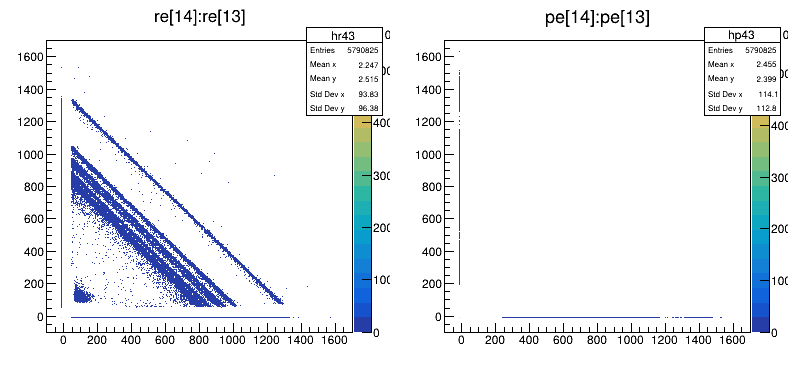

In [4]:
tree->Draw("re[14]:re[13]>>hr43(800,-100,1700,800,-100,1700)","","goff");//goff 选项：只填充hist，而不显示。
tree->Draw("pe[14]:pe[13]>>hp43(800,-100,1700,800,-100,1700)","","goff");
c1->Divide(2,1);
c1->cd(1);      
hr43->Draw("colz");
c1->cd(2);       
hp43->Draw("colz");
c1->Draw();


<h2 id="Effect-on-Single-Strip-Spectra">Effect on Single-Strip Spectra</h2><p>Adjacent-strip sharing broadens the spectrum of a single strip. Therefore, single-strip calibration and adjacent-strip reconstruction should be treated separately.</p>
<ul>
<li>The red spectrum contains events affected by adjacent-strip sharing, while the black spectrum contains isolated single-strip events. The difference between them shows why inter-strip events must be handled explicitly.</li>
</ul>


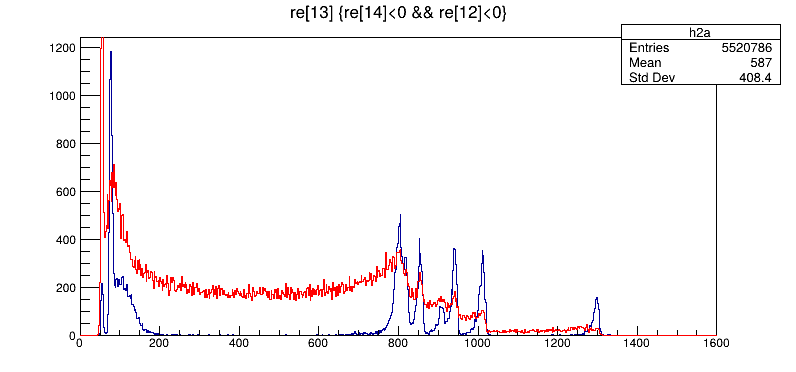

In [6]:
c1->Divide(1,1);
c1->cd();
tree->Draw("re[13]>>h1a(800,0,1600)","re[14]>0 || re[12]>0");// 有相邻条能量共享
TH1F *h1a = (TH1F*)gROOT->FindObject("h1a");
tree->Draw("re[13]>>h2a(800,0,1600)","re[14]<0 && re[12]<0");// 没有相邻条能量共享
h1a->SetLineColor(kRed);
h1a->Draw("same");
c1->Draw();


<h2 id="Selection-of-Two-Reference-Bands">Selection of Two Reference Bands</h2><p>Here the graphical cuts are assumed to be already prepared. Their construction is not discussed in this lecture. We only use them as event selections.</p>
<ul>
<li><code>cut1</code> corresponds to the $8.6931$ MeV $\alpha$ line.</li>
<li><code>cut2</code> corresponds to the $6.6708$ MeV $\alpha$ line.</li>
</ul>
<p><img alt="" src="fig/tcutg.png"/></p>


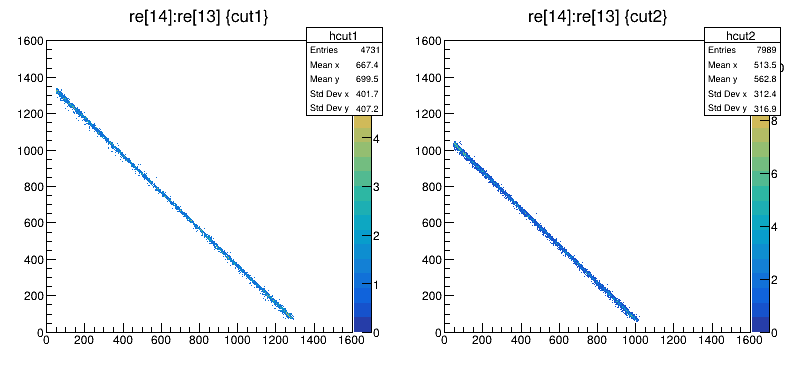

In [8]:
gROOT->Macro("cut1.C");
gROOT->Macro("cut2.C");

c1->Clear();
c1->Divide(2,1);
c1->cd(1);      
tree->Draw("re[14]:re[13]>>hcut1(800,0,1600,800,0,1600)","cut1","colz");
c1->cd(2);
tree->Draw("re[14]:re[13]>>hcut2(800,0,1600,800,0,1600)","cut2","colz");
c1->Draw();


<h2 id="Energy-Sharing-Model">Energy-Sharing Model</h2><p>Let the ADC amplitudes of strips $i$ and $i+1$ be $A_i$ and $A_{i+1}$. Their calibrated energies are</p>
<p>$$
E_i = k_i A_i + b_i,
\qquad
E_{i+1} = k_{i+1} A_{i+1} + b_{i+1}.
$$</p>
<p>For one particle,</p>
<p>$$
E = E_i + E_{i+1} = k_i A_i + k_{i+1} A_{i+1} + (b_i+b_{i+1}).
$$
Therefore, the adjacent-strip correlation follows a straight line:</p>
<p>$$
A_{i+1} = K \cdot A_i + B,
$$</p>
<p>with</p>
<p>$$
K=-\frac{k_i}{k_{i+1}},
\qquad
B=\frac{E-(b_i+b_{i+1})}{k_{i+1}}.
$$</p>
<p>Using two mono-energetic bands, we obtain $K$, $B$, and then solve for $k_i$, $k_{i+1}$, and $b_i+b_{i+1}$.</p>
<p>两个能量已知的条带给出两个斜率和截距。斜率在误差内一致时，可用共同斜率求增益比；这里只能求出截距之和，不能单独确定每条的截距。</p>


<h2 id="Linear-Fits">Linear Fits</h2><ul>
<li>Convert TH2 to TGraph <a href="https://root.cern.ch/root/roottalk/roottalk03/0638.html">https://root.cern.ch/root/roottalk/roottalk03/0638.html</a></li>
</ul>
<pre><code>tree::Draw("x1:x2",selection);
TGraph *gr = new TGraph(tree-&gt;GetSelectedRows(), tree-&gt;GetV2(), tree-&gt;GetV1());
</code></pre>
<p><code>GetV1/GetV2</code> 按 Draw 表达式的顺序返回数值。先设置 <code>SetEstimate</code>，避免所选事例数超过内部缓冲区。TGraph 拷贝这些值；下一次 Draw 会刷新原缓冲区。</p>

In [ ]:
TGraph *gr1, *gr2;
TF1 *f1, *f2;

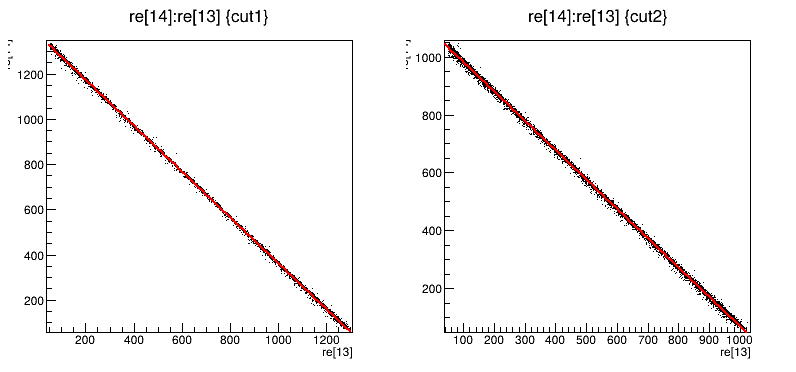

In [12]:
tree->SetEstimate(tree->GetEntries()+1);
c1->Clear();
c1->Divide(2,1);
c1->cd(1); 

tree->Draw("re[14]:re[13]","cut1","");
gr1 = new TGraph(tree->GetSelectedRows(), tree->GetV2(), tree->GetV1());
gr1->Fit("pol1","Q");
f1 = gr1->GetFunction("pol1");
f1->Draw("same");

c1->cd(2);
tree->Draw("re[14]:re[13]","cut2","");
gr2 = new TGraph(tree->GetSelectedRows(), tree->GetV2(), tree->GetV1());
gr2->Fit("pol1","Q");
f2 = gr2->GetFunction("pol1");
f2->Draw("same");
c1->Draw();


<h2 id="Parameter-Extraction">Parameter Extraction</h2>


In [14]:
double E1 = 8.6931;
double E2 = 6.6708;
double K13,K14,K,B13,B14,k13,k14,b13_14;

K13 = f1->GetParameter(1);
K14 = f2->GetParameter(1);
K  = (K13 + K14)/2.0;

B13 = f1->GetParameter(0);
B14 = f2->GetParameter(0);

k14  = (E1-E2)/(B13-B14);
k13  = -K*k14;
b13_14 = E1 - k14*B13;

cout << Form("k13 = %f, k14 = %f, b13 + b14 = %f",k13,k14,b13_14) << endl;

k13 = 0.007014, k14 = 0.006918, b13 + b14 = -0.826077


<h2 id="Energy-Reconstruction">Energy Reconstruction</h2><p>After reconstruction, the shared events are converted into a total-energy spectrum. In practical analysis, this is the key step: identify the adjacent-strip event, reconstruct the cluster energy, and then keep the event in the later analysis chain. Recent detector studies also show that interstrip events can be reconstructed effectively rather than treated as unusable events.</p>
<p>这里的直线拟合是初步刻度：两条的幅度都有涨落，普通 TGraph 的最小二乘只处理纵向残差。需要精确参数误差时，应使用含两轴误差的拟合，并传播斜率与截距的 covariance。</p>

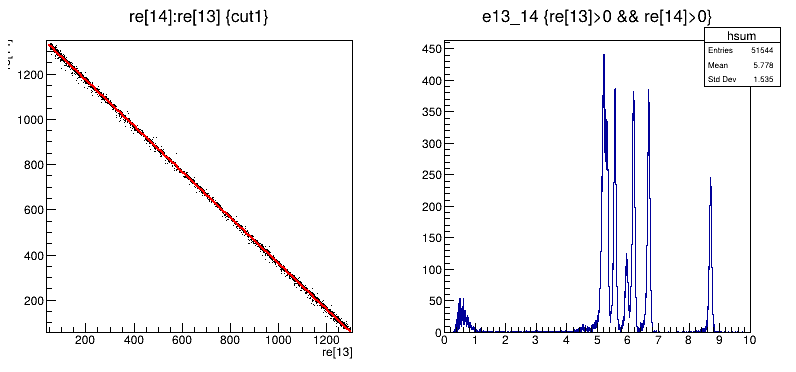

In [16]:
tree->SetAlias("e13_14",Form("%f*re[13] + %f*re[14] + %f",k13,k14,b13_14));
tree->Draw("e13_14>>hsum(2000,0,10)","re[13]>0 && re[14]>0");
c1->Draw();


<h2 id="Position-Reconstruction">Position Reconstruction</h2><p>An adjacent-strip event should not be treated automatically as a particle hitting exactly at the geometrical gap. In real data, two neighboring strips may fire because of true interstrip charge sharing, but also because of impact position, impact angle, coupling, or other detector-response effects. The useful subset is the clean two-strip sharing event.</p>
<p>For position analysis, the practical rule is simple:</p>
<ul>
<li>exactly two adjacent strips carry the signal;</li>
<li>both signals are positive and above threshold;</li>
<li>no extra neighboring strip participates;</li>
<li>the summed energy is consistent with one particle.</li>
</ul>
<p>For such events, the charge ratio contains position information inside one strip pitch. A simple position estimator is the energy-weighted centroid,</p>
<p>$$
x_c=\frac{E_i x_i + E_{i+1} x_{i+1}}{E_i+E_{i+1}}.
$$</p>
<p>This gives a continuous position estimate and is more informative than assigning the event only to the strip with the larger signal. In this sense, clean adjacent-strip events can be used for position refinement beyond the digital strip index, while still preserving the deposited energy.</p>
<p>能量重心是位置估计量，不等于已验证的亚条位置分辨率；还需用已知位置数据检查电荷比—位置关系。电荷损失和电子学串扰也不能只靠相邻双击来区分。</p>